In [58]:
from pathlib import Path

import pandas as pd

base_dir = Path('synthesibility_results')
model_paths_dict = {
    'SCENT (C+D+P)': 'rgfn_new_filtered/seh/dyn_lib_reward_exploitation_pen_none',
    'SCENT (C+D+P) smaller': 'rgfn_new_filtered/seh/rgfn_smaller',
    'RGFN': 'rgfn_new_filtered/seh/rgfn_old',
    'RGFN smaller': 'rgfn_new_filtered/seh/rgfn_old_smaller',
    'REINVENT': 'unconstrained/seh/reinvent',
    'Graph GA': 'unconstrained/seh/graph_ga',
    'FGFN': 'unconstrained/seh/fgfn',
    'FGFN (SA)': 'unconstrained/seh/fgfn_sas',
}
all_dfs = []
for model, model_path in model_paths_dict.items():
    for seed in range(2):
        file_path = base_dir / model_path / f'sampling/OUT_molecules_{seed}_augmented_cost.csv'
        if not file_path.exists():
            file_path = base_dir / model_path / f'sampling/OUT_molecules_{seed}_augmented.csv'
        print(f"Reading {file_path}")
        df = pd.read_csv(file_path)
        df['model'] = model
        df['model_space'] = model.replace(' ', '\n')
        all_dfs.append(df)
df = pd.concat(all_dfs, ignore_index=True)

Reading synthesibility_results/rgfn_new_filtered/seh/dyn_lib_reward_exploitation_pen_none/sampling/OUT_molecules_0_augmented_cost.csv
Reading synthesibility_results/rgfn_new_filtered/seh/dyn_lib_reward_exploitation_pen_none/sampling/OUT_molecules_1_augmented_cost.csv
Reading synthesibility_results/rgfn_new_filtered/seh/rgfn_smaller/sampling/OUT_molecules_0_augmented.csv
Reading synthesibility_results/rgfn_new_filtered/seh/rgfn_smaller/sampling/OUT_molecules_1_augmented.csv
Reading synthesibility_results/rgfn_new_filtered/seh/rgfn_old/sampling/OUT_molecules_0_augmented_cost.csv
Reading synthesibility_results/rgfn_new_filtered/seh/rgfn_old/sampling/OUT_molecules_1_augmented_cost.csv
Reading synthesibility_results/rgfn_new_filtered/seh/rgfn_old_smaller/sampling/OUT_molecules_0_augmented.csv
Reading synthesibility_results/rgfn_new_filtered/seh/rgfn_old_smaller/sampling/OUT_molecules_1_augmented.csv
Reading synthesibility_results/unconstrained/seh/reinvent/sampling/OUT_molecules_0_augmented

In [71]:
def plot_novelty_tradeoff(df, filter_synthesizability=True, filter_diversity=False, models = ('FGFN (SA)', 'SCENT (C+D+P)',  'REINVENT'), reverse_zorder=True):
    model_alpha = {
        'SCENT (C+D+P)': 0.1,
        'FGFN (SA)': 0.1,
        'REINVENT': 0.1,
        'Graph GA': 0.1,
    }
    for i, model in enumerate(models):
        sub_df = df[df['model'] == model]
        if filter_synthesizability:
            sub_df = sub_df[sub_df['avg_aizynth_zinc_top_1000'] == 1]
        if filter_diversity:
            sub_df = sub_df.sort_values('proxy', ascending=False)
            datapoints = []
            mode_fps = []
            for _, row in sub_df.iterrows():
                fp = _get_fp(row['smiles'], 'morgan_3')
                similarities = DataStructs.BulkTanimotoSimilarity(fp, mode_fps)
                if len(similarities) == 0 or max(similarities) < 0.5:
                    mode_fps.append(fp)
                    datapoints.append(row)
            x_values = np.array([d['proxy'] for d in datapoints])
            y_values = np.array([d['novelty'] for d in datapoints])
        else:
            x_values = sub_df['proxy']
            y_values = sub_df['novelty']
        
        zorder = len(models) - i if reverse_zorder else i
        plt.scatter(x_values, y_values, label=model, alpha=model_alpha[model], s=100, zorder=zorder)
        plt.plot(x_values.mean(), y_values.mean(), '+', markersize=30, markeredgewidth=4, color='black', zorder=10)
        plt.plot(x_values.mean(), y_values.mean(), '+', markersize=29, markeredgewidth=3, zorder=10)

    plt.title("Reward vs Novelty Tradeoff", fontsize=16)  # Or set a specific title if needed
    plt.xlabel('Reward', fontsize=14)
    plt.ylabel('Novelty', fontsize=14)
    plt.xlim(6.0)
    plt.ylim(0.3)
    leg = plt.legend()
    for handle in leg.legend_handles:
        handle.set_alpha(1.0)  # Make legend fully opaque

In [60]:
df

,smiles,valid,sc_score,qed_score,mol_weight,sa_score,avg_aizynth_zinc_top_1000,novelty_all,proxy,novelty,diversity,cost,model,model_space
0,O=C(Nc1ccnc2ccccc12)c1ccc2nc(-c3ccc(Cn4nnc(-c5...,1,4.883715,0.183548,661.291371,4.126169,1.0,1,7.942895,0.573034,0.805896,12.545847,SCENT (C+D+P),SCENT\n(C+D+P)
1,N#Cc1ccc(CN2CCC[C@H]2c2nc3cc(-c4cccc(NC(=O)NC5...,1,4.996853,0.385152,478.211724,3.125880,1.0,1,7.414505,0.595506,0.846563,3.196297,SCENT (C+D+P),SCENT\n(C+D+P)
2,Nc1ccc(-c2ccc3nc(-c4ccc(CNc5ccccc5C(=O)Nc5cccc...,1,4.903053,0.199246,511.200825,2.382869,1.0,1,6.739612,0.453125,0.858090,2.601254,SCENT (C+D+P),SCENT\n(C+D+P)
3,O=C(NC1CC1)c1ccc(Cn2cc(CCN(C[C@@H]3Cc4ccccc4CN...,1,4.767118,0.251431,589.341676,3.620554,0.0,1,7.546720,0.571429,0.823561,9.228376,SCENT (C+D+P),SCENT\n(C+D+P)
4,O=C(NC12CC(C1)C2)c1cccc(-c2cc(NC(=O)C3CN(C(=O)...,1,4.826347,0.540366,434.206639,3.624592,1.0,1,5.738852,0.552239,0.847196,27.650705,SCENT (C+D+P),SCENT\n(C+D+P)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15995,Cc1ccccc1C(=O)NCc1nccc(-c2cccc(-c3ccccc3-c3ccc...,1,4.641362,0.192876,561.241627,2.439997,1.0,1,6.561983,0.561644,0.833351,NaN,FGFN (SA),FGFN\n(SA)
15996,O=C(NCc1ccccc1)NCc1ccccc1-c1ccc(-c2cc(-n3ccc(-...,1,4.999996,0.123671,595.233188,2.709459,0.0,1,6.971376,0.571429,0.839299,NaN,FGFN (SA),FGFN\n(SA)
15997,O=C(NCc1ccccc1CNC(=O)c1cc(-c2ccnc(-c3cccc(-c4c...,1,4.373022,0.139824,638.268176,2.651605,1.0,1,7.962801,0.530303,0.826079,NaN,FGFN (SA),FGFN\n(SA)
15998,N#Cc1ccn(-c2ccnc(-c3ccc(F)cc3-c3nc(-c4c(C=N)cc...,1,4.998677,0.266354,544.123006,3.567619,NaN,1,4.293592,0.662791,0.899088,NaN,FGFN (SA),FGFN\n(SA)


/var/folders/5d/02_f0b1n3s9dx9kzhkqmt2cw0000gn/T/ipykernel_24882/3920781322.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=sub_df["model_space"], y=sub_df[metric], inner='box', palette='muted')
/var/folders/5d/02_f0b1n3s9dx9kzhkqmt2cw0000gn/T/ipykernel_24882/3920781322.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=sub_df["model_space"], y=sub_df[metric], inner='box', palette='muted')
/var/folders/5d/02_f0b1n3s9dx9kzhkqmt2cw0000gn/T/ipykernel_24882/3920781322.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=sub

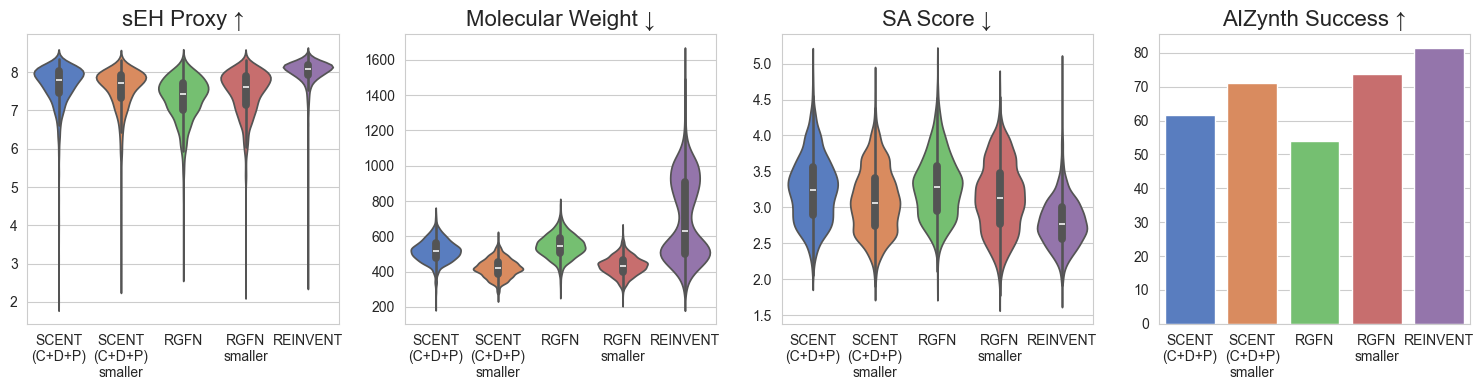

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

violin_metrics_dict = {
    'proxy': 'sEH Proxy \u2191',
    'mol_weight': 'Molecular Weight \u2193',
    'sa_score': 'SA Score \u2193',
    # 'sc_score': 'SC Score \u2193',
    # 'qed_score': 'QED \u2191',
    # 'diversity': 'Diversity \u2191',
    # 'novelty': 'Novelty \u2191',
    
}
model_color = {
    'SCENT (C+D+P)': 'blue',
    'RGFN': 'orange',
    'REINVENT': 'green',
    'FGFN': 'red',
    'FGFN (SA)': 'purple',
}
sub_df = df[df['model'].isin(['SCENT (C+D+P)', 'RGFN', 'SCENT (C+D+P) smaller', 'RGFN smaller', 'REINVENT'])]
plt.figure(figsize=(15, 4))
for i, (metric, title) in enumerate(violin_metrics_dict.items()):
    plt.subplot(1, len(violin_metrics_dict) + 1, i + 1)
    
    sns.violinplot(x=sub_df["model_space"], y=sub_df[metric], inner='box', palette='muted')
    plt.xlabel('')
    plt.ylabel('')
    plt.title(title, fontsize=16)

plt.subplot(1, len(violin_metrics_dict) + 1, len(violin_metrics_dict) + 1)
sns.barplot(x=sub_df['model_space'], y=sub_df['avg_aizynth_zinc_top_1000'] * 100, data=sub_df, palette='muted', errorbar=None)
plt.xlabel('')
plt.ylabel('')
plt.title('AIZynth Success \u2191', fontsize=16)
plt.tight_layout()
plt.savefig('synthesizibility_violin.pdf', bbox_inches='tight')

/var/folders/5d/02_f0b1n3s9dx9kzhkqmt2cw0000gn/T/ipykernel_24882/3396694014.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=synthesible_df["model_space"], y=synthesible_df[metric], inner='box', palette='muted')
/var/folders/5d/02_f0b1n3s9dx9kzhkqmt2cw0000gn/T/ipykernel_24882/3396694014.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=synthesible_df["model_space"], y=synthesible_df[metric], inner='box', palette='muted')
/var/folders/5d/02_f0b1n3s9dx9kzhkqmt2cw0000gn/T/ipykernel_24882/3396694014.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same

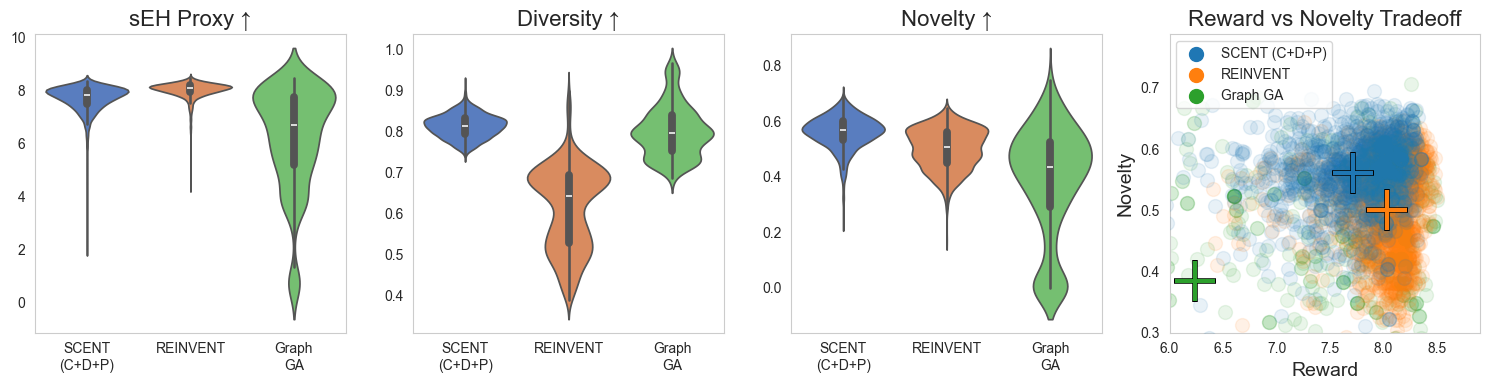

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

violin_metrics_dict = {
    'proxy': 'sEH Proxy \u2191',
    # 'mol_weight': 'Molecular Weight \u2193',
    # 'sa_score': 'SA Score \u2193',
    # 'sc_score': 'SC Score \u2193',
    # 'qed_score': 'QED \u2191',
    'diversity': 'Diversity \u2191',
    'novelty': 'Novelty \u2191',
    
}
sub_df = df[df['model'].isin(['SCENT (C+D+P)', 'REINVENT', 'Graph GA'])]
plt.figure(figsize=(15, 4))
for i, (metric, title) in enumerate(violin_metrics_dict.items()):
    plt.subplot(1, len(violin_metrics_dict) + 1, i + 1)
    synthesible_df = sub_df[sub_df['avg_aizynth_zinc_top_1000'] == 1]
    sns.violinplot(x=synthesible_df["model_space"], y=synthesible_df[metric], inner='box', palette='muted')
    plt.xlabel('')
    plt.ylabel('')
    plt.title(title, fontsize=16)
    plt.grid(False)  # Remove grid

plt.subplot(1, len(violin_metrics_dict) + 1, len(violin_metrics_dict) + 1)
plot_novelty_tradeoff(sub_df, filter_synthesizability=True, filter_diversity=False, models=['SCENT (C+D+P)', 'REINVENT', 'Graph GA'])
plt.tight_layout()
# plt.annotate('', xy=(1, 1), xytext=(0.9, 0.9),
#              xycoords='axes fraction',  # Normalized coordinates
#              arrowprops=dict(facecolor='black', edgecolor='black', arrowstyle='->', linewidth=2))
plt.grid(False)  # Remove grid
plt.savefig('novelty_tradeoff.pdf', bbox_inches='tight')

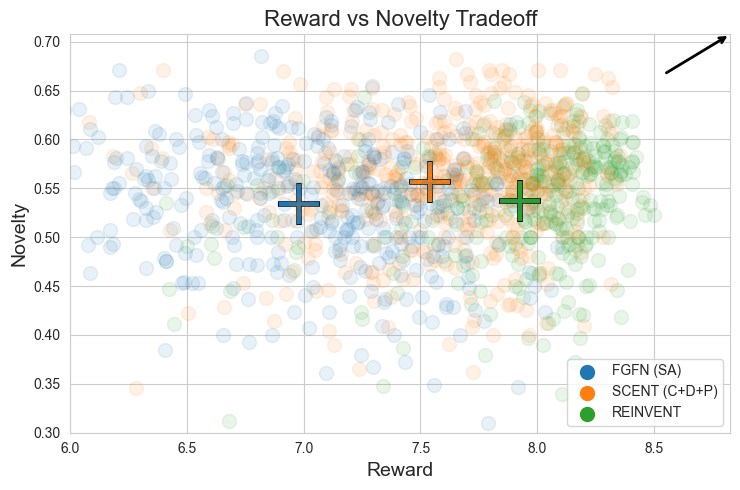

In [63]:
from rdkit import DataStructs
from notebooks.utils.common import _get_fp



    

versions = [(True, True)]
plt.figure(figsize=(7.5 * len(versions), 5))
for i, v in enumerate(versions):
    plt.subplot(1, len(versions), i + 1)
    plot_novelty_tradeoff(df, *v)
    
plt.annotate('', xy=(1, 1), xytext=(0.9, 0.9),
             xycoords='axes fraction',  # Normalized coordinates
             arrowprops=dict(facecolor='black', edgecolor='black', arrowstyle='->', linewidth=2))
plt.tight_layout()
plt.savefig('reward_novelty_tradeoff.pdf', bbox_inches='tight')

In [64]:
# def plot_cost_tradeoff(df, filter_synthesizability=True, filter_diversity=False):
#     model_alpha = {
#         'SCENT (C+D+P)': 0.2,
#         'RGFN': 0.2,
#         'REINVENT': 0.1,
#     }
#     for model in ['RGFN', 'SCENT (C+D+P)']:
#         sub_df = df[df['model'] == model]
#         if filter_synthesizability:
#             sub_df = sub_df[sub_df['avg_aizynth_zinc_top_1000'] == 1]
#         if filter_diversity:
#             sub_df = sub_df.sort_values('proxy', ascending=False)
#             datapoints = []
#             mode_fps = []
#             for _, row in sub_df.iterrows():
#                 fp = _get_fp(row['smiles'], 'morgan_3')
#                 similarities = DataStructs.BulkTanimotoSimilarity(fp, mode_fps)
#                 if len(similarities) == 0 or max(similarities) < 0.5:
#                     mode_fps.append(fp)
#                     datapoints.append(row)
#             x_values = np.array([d['proxy'] for d in datapoints])
#             y_values = np.array([d['cost'] for d in datapoints])
#         else:
#             x_values = sub_df['proxy']
#             y_values = sub_df['cost']
#             
#         plt.scatter(x_values, y_values, alpha=model_alpha[model], label=model, s=100)
#         plt.plot(x_values.mean(), y_values.mean(), '+', markersize=30, markeredgewidth=4, color='black')
#         plt.plot(x_values.mean(), y_values.mean(), '+', markersize=29, markeredgewidth=3)
# 
#     plt.title("Reward vs Synthesis Cost Tradeoff", fontsize=16)  # Or set a specific title if needed
#     plt.xlabel('Reward', fontsize=14)
#     plt.ylabel('Synthesis Cost', fontsize=14)
#     plt.xlim(6.0)
#     # plt.yscale('log')
#     plt.ylim(4e-1, 1e2)
#     # optimal point
#     # plt.plot(8.65, 2.0, '*', markersize=7, color='black', label='optimal')
#     leg = plt.legend()
#     for handle in leg.legend_handles:
#         handle.set_alpha(1.0)  # Make legend fully opaque
# 
# versions = [(True, True)]
# plt.figure(figsize=(7.5 * len(versions), 5))
# for i, v in enumerate(versions):
#     plt.subplot(1, len(versions), i + 1)
#     plot_cost_tradeoff(df, *v)
# plt.annotate('',xytext=(0.9, 0.1), xy=(1.0, 0.0),
#              xycoords='axes fraction',  # Normalized coordinates
#              arrowprops=dict(facecolor='black', edgecolor='black', arrowstyle='->', linewidth=2))
# 
# plt.tight_layout()
# plt.savefig('reward_cost_tradeoff.pdf', bbox_inches='tight')
#     

NameError: name 'plot_cost_tradeoff' is not defined

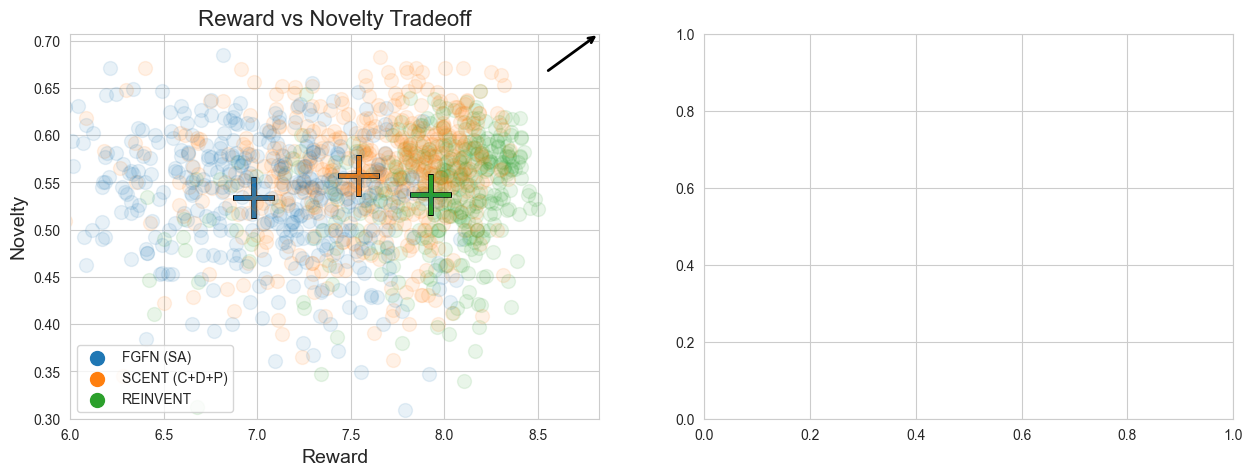

In [65]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plot_novelty_tradeoff(df, True, True)
plt.annotate('', xy=(1, 1), xytext=(0.9, 0.9),
             xycoords='axes fraction',  # Normalized coordinates
             arrowprops=dict(facecolor='black', edgecolor='black', arrowstyle='->', linewidth=2))

plt.subplot(1, 2, 2)
plot_cost_tradeoff(df,  True, True)
plt.annotate('',xytext=(0.9, 0.1), xy=(1.0, 0.0),
             xycoords='axes fraction',  # Normalized coordinates
             arrowprops=dict(facecolor='black', edgecolor='black', arrowstyle='->', linewidth=2))
plt.tight_layout()
plt.savefig('tradeoffs.pdf', bbox_inches='tight')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_cost_tradeoff(df, filter_synthesizability=True, filter_diversity=False):
    plt.figure(figsize=(6, 6))

    for model in ['SCENT (C+D+P)', 'RGFN']:
        sub_df = df[df['model'] == model]
        
        if filter_synthesizability:
            sub_df = sub_df[sub_df['avg_aizynth_zinc_top_1000'] == 1]
        
        if filter_diversity:
            sub_df = sub_df.sort_values('proxy', ascending=False)
            datapoints = []
            mode_fps = []
            for _, row in sub_df.iterrows():
                fp = _get_fp(row['smiles'], 'morgan_3')
                similarities = DataStructs.BulkTanimotoSimilarity(fp, mode_fps)
                if len(similarities) == 0 or max(similarities) < 0.5:
                    mode_fps.append(fp)
                    datapoints.append(row)
            sub_df = pd.DataFrame(datapoints)  # Use filtered data for KDE

        if len(sub_df) >= 10:
            sns.kdeplot(
                data=sub_df, x='proxy', y='cost', 
                fill=True, cmap='Blues' if model == 'SCENT (C+D+P)' else 'Oranges',
                alpha=0.6, thresh=0.05, levels=100, label=model
            )
            # Mean point
            mean_x = sub_df['proxy'].mean()
            mean_y = sub_df['cost'].mean()
            plt.plot(mean_x, mean_y, 'o', label=f'{model} Mean', markersize=6)
        else:
            print(f"Not enough data for KDE in model: {model}")
            plt.scatter(sub_df['proxy'], sub_df['cost'], alpha=0.3, label=f'{model} (scatter)')

    plt.title("Model Comparison (Contour with Means)")
    plt.xlabel('Reward')
    plt.ylabel('Cost')
    plt.xlim(6.0)
    plt.yscale('log')
    plt.ylim(0, 2e2)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_cost_tradeoff(df, filter_diversity=False)